# 03 — Modelling & Evaluation

Compares four xG models on international tournament test data:
- Distance-only baseline (naive)
- Logistic regression (interpretable)
- Random forest (non-linear)
- XGBoost (gradient boosting)

**Key principle:** Accuracy is the wrong metric. A model predicting "no goal" every time gets ~89% accuracy. We evaluate on **log loss**, **Brier score** (calibration), and **AUC-ROC** (discrimination).

**Train/test split:** Trained on club football (La Liga, Premier League, etc.), tested on international tournaments (World Cup 2022, Euro 2024, Women's World Cup 2023). This tests genuine generalisation.

In [1]:
import sys
import os
sys.path.insert(0, "..")
os.chdir("..")

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

from src.features.build_features import FEATURE_COLUMNS, TARGET
from src.evaluation.evaluate import (
    MODEL_NAMES, MODEL_DISPLAY, MODEL_COLORS,
    load_models, load_test_data, predict, compute_metrics,
)

sns.set_theme(style="whitegrid")

models = load_models()
test_df = load_test_data()
train_df = pd.read_parquet("data/processed/train.parquet")

print(f"Train: {len(train_df):,} shots ({train_df[TARGET].mean():.1%} goal rate)")
print(f"Test:  {len(test_df):,} shots ({test_df[TARGET].mean():.1%} goal rate)")
print(f"Test competitions: {test_df['competition'].unique().tolist()}")

Train: 83,509 shots (11.1% goal rate)
Test:  4,514 shots (11.2% goal rate)
Test competitions: ['FIFA World Cup', 'UEFA Euro', "Women's World Cup"]


## Model comparison: metrics table

In [2]:
y_true = test_df[TARGET].values
results = {}

with open("models/training_summary.json") as f:
    train_summary = json.load(f)

rows = []
for name in MODEL_NAMES:
    features = FEATURE_COLUMNS if name != "distance_only" else ["distance_to_goal"]
    y_pred = predict(models[name], test_df, features)
    metrics = compute_metrics(y_true, y_pred)
    results[name] = {"metrics": metrics, "predictions": y_pred}
    
    rows.append({
        "Model": MODEL_DISPLAY[name],
        "CV Log Loss": f"{train_summary[name]['cv_log_loss']:.4f}",
        "Test Log Loss": f"{metrics['log_loss']:.4f}",
        "Brier Score": f"{metrics['brier_score']:.4f}",
        "AUC-ROC": f"{metrics['auc_roc']:.4f}",
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

              Model CV Log Loss Test Log Loss Brier Score AUC-ROC
      Distance Only      0.3111        0.3166      0.0927  0.7284
Logistic Regression      0.2680        0.2569      0.0727  0.8385
      Random Forest      0.2643        0.2526      0.0706  0.8402
            XGBoost      0.2628        0.2482      0.0693  0.8442


## Calibration curves

The single most important chart for an xG model. If the model says "30% chance", roughly 30% of those shots should actually be goals.

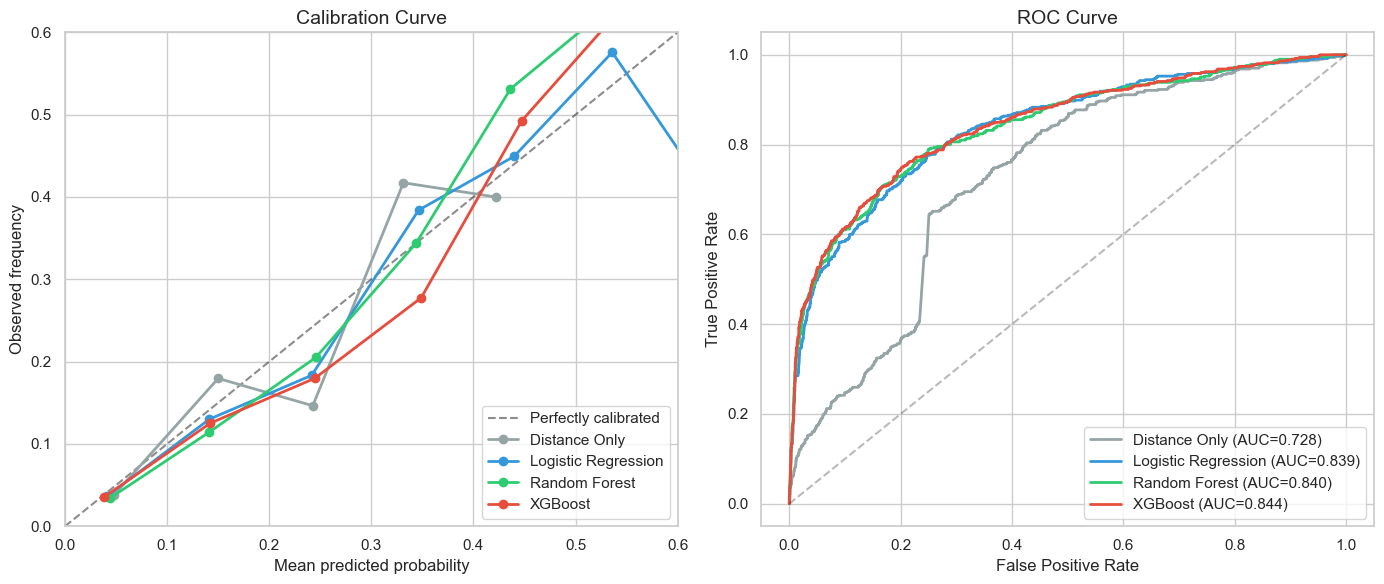

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calibration curve
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated", alpha=0.5)

for name in MODEL_NAMES:
    y_pred = results[name]["predictions"]
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o", label=MODEL_DISPLAY[name], color=MODEL_COLORS[name], linewidth=2)

ax.set_xlabel("Mean predicted probability", fontsize=12)
ax.set_ylabel("Observed frequency", fontsize=12)
ax.set_title("Calibration Curve", fontsize=14)
ax.legend(loc="lower right")
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)

# ROC curves
ax = axes[1]
for name in MODEL_NAMES:
    y_pred = results[name]["predictions"]
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc = results[name]["metrics"]["auc_roc"]
    ax.plot(fpr, tpr, label=f"{MODEL_DISPLAY[name]} (AUC={auc:.3f})", color=MODEL_COLORS[name], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve", fontsize=14)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Metrics comparison bar chart

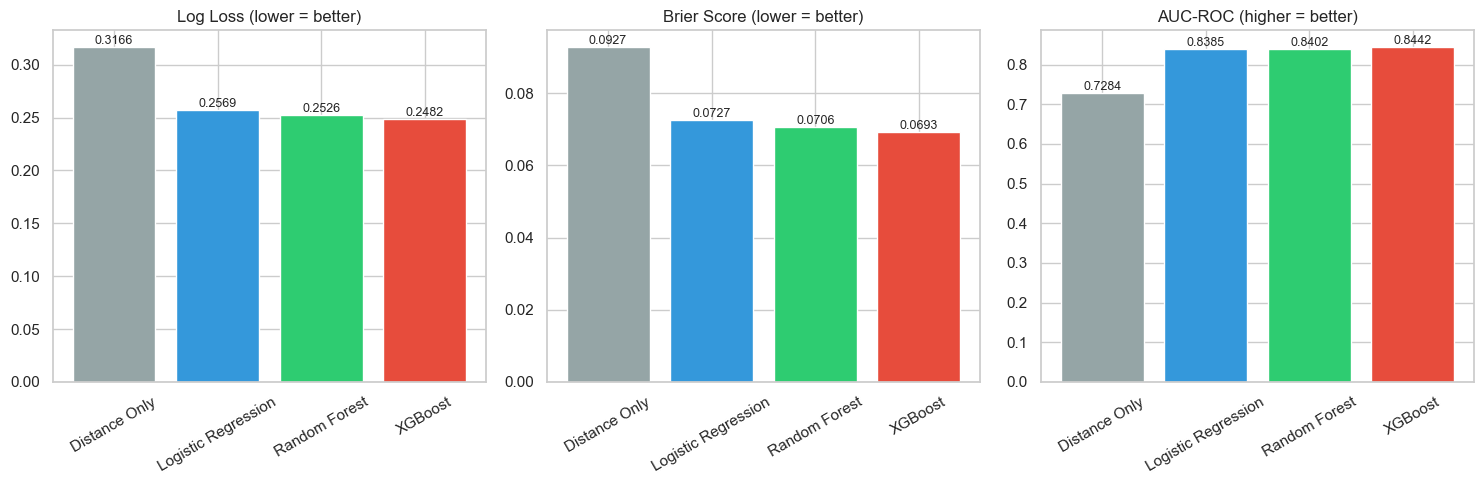

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_data = {MODEL_DISPLAY[n]: results[n]["metrics"] for n in MODEL_NAMES}
metrics_df = pd.DataFrame(metrics_data).T

for ax, metric, title in zip(
    axes,
    ["log_loss", "brier_score", "auc_roc"],
    ["Log Loss (lower = better)", "Brier Score (lower = better)", "AUC-ROC (higher = better)"],
):
    colors = [MODEL_COLORS[n] for n in MODEL_NAMES]
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## SHAP feature importance (XGBoost)

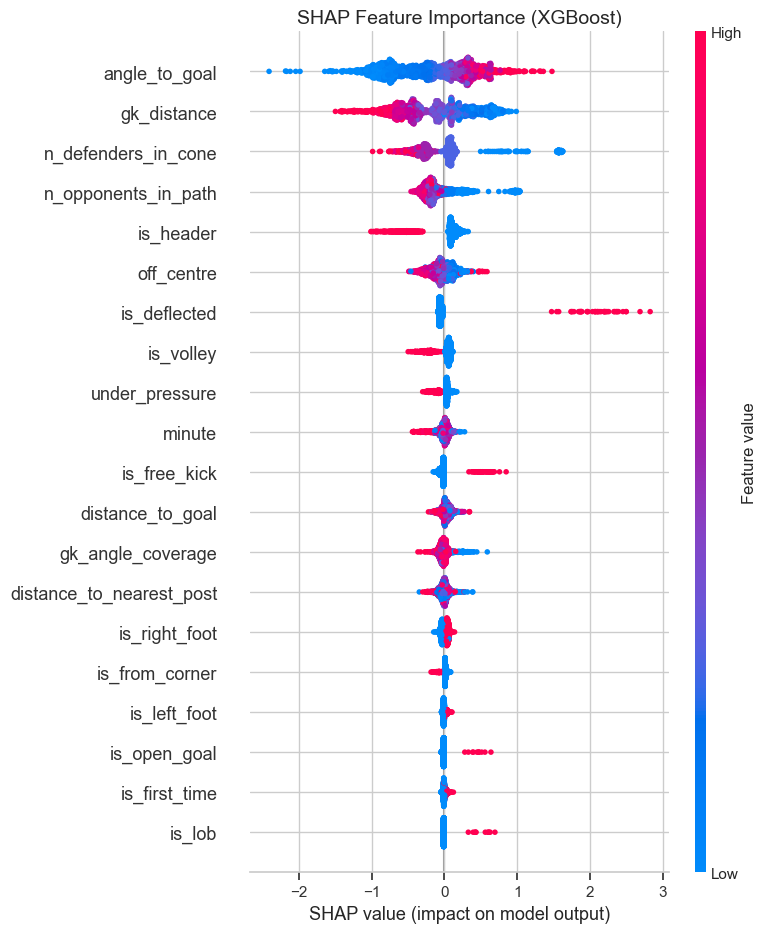

In [5]:
import shap

# Get the XGBoost model from the pipeline
xgb_pipeline = models["xgboost"]
xgb_model = xgb_pipeline.named_steps["model"]

# Transform test features through preprocessing
X_test = test_df[FEATURE_COLUMNS].values
X_test_transformed = xgb_pipeline.named_steps["preprocess"].transform(X_test)

# Use a sample for speed
sample_idx = np.random.RandomState(42).choice(len(X_test_transformed), min(2000, len(X_test_transformed)), replace=False)
X_sample = X_test_transformed[sample_idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLUMNS, show=False)
plt.title("SHAP Feature Importance (XGBoost)", fontsize=14)
plt.tight_layout()
plt.show()

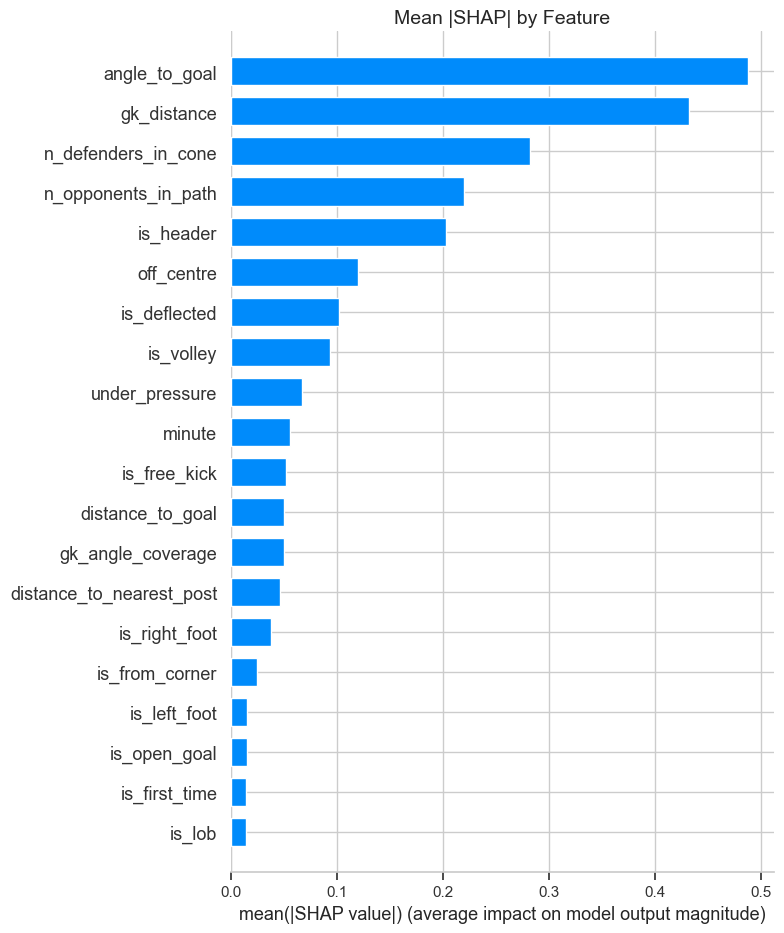

In [6]:
# Mean absolute SHAP values (bar plot)
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLUMNS, plot_type="bar", show=False)
plt.title("Mean |SHAP| by Feature", fontsize=14)
plt.tight_layout()
plt.show()

## Comparison with StatsBomb xG

       Model log_loss brier_score auc_roc
 Our XGBoost   0.2482      0.0693  0.8442
StatsBomb xG   0.2575      0.0726  0.8375


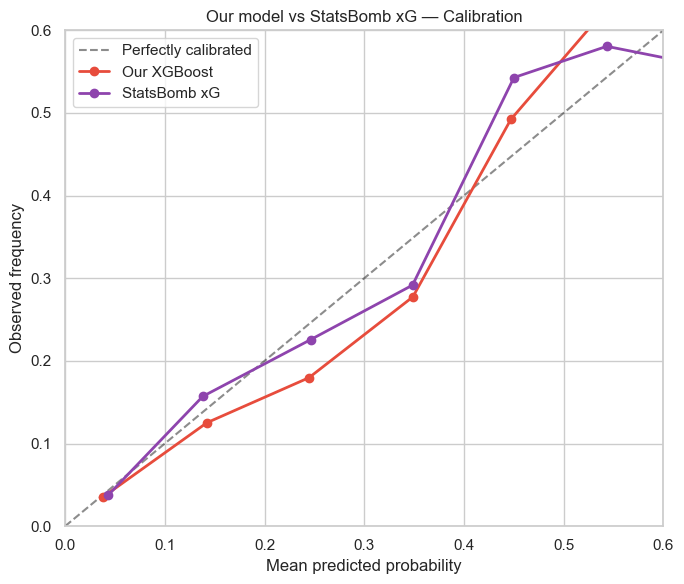

In [7]:
# Compare our best model (XGBoost) to StatsBomb's xG
sb_metrics = compute_metrics(y_true, test_df["shot_statsbomb_xg"].values)
xgb_metrics = results["xgboost"]["metrics"]

comp_rows = [
    {"Model": "Our XGBoost", **{k: f"{v:.4f}" for k, v in xgb_metrics.items() if k != 'cv_log_loss'}},
    {"Model": "StatsBomb xG", **{k: f"{v:.4f}" for k, v in sb_metrics.items()}},
]
print(pd.DataFrame(comp_rows).to_string(index=False))

# Calibration comparison
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated", alpha=0.5)

for label, preds, color in [
    ("Our XGBoost", results["xgboost"]["predictions"], "#e74c3c"),
    ("StatsBomb xG", test_df["shot_statsbomb_xg"].values, "#8e44ad"),
]:
    prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o", label=label, color=color, linewidth=2)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Our model vs StatsBomb xG — Calibration")
ax.legend()
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

## Prediction distribution

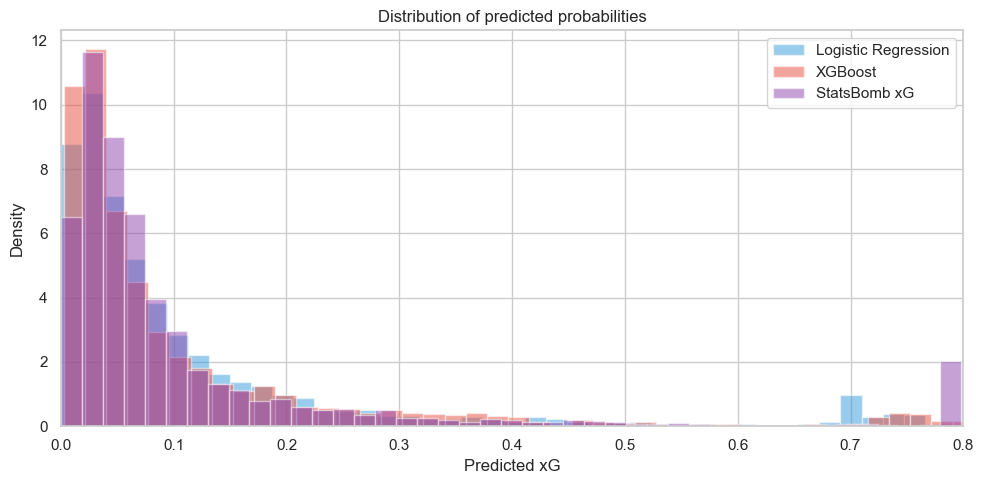

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in ["logistic_regression", "xgboost"]:
    y_pred = results[name]["predictions"]
    ax.hist(y_pred, bins=50, alpha=0.5, label=MODEL_DISPLAY[name], color=MODEL_COLORS[name], density=True)

ax.hist(test_df["shot_statsbomb_xg"], bins=50, alpha=0.5, label="StatsBomb xG", color="#8e44ad", density=True)
ax.set_xlabel("Predicted xG")
ax.set_ylabel("Density")
ax.set_title("Distribution of predicted probabilities")
ax.legend()
ax.set_xlim(0, 0.8)
plt.tight_layout()
plt.show()

## Key findings

### Model ranking (by log loss on international tournament test set)
1. **XGBoost** — best overall, captures non-linear interactions between features
2. **Random Forest** — close second, slightly less calibrated
3. **Logistic Regression** — solid baseline, surprisingly competitive
4. **Distance Only** — significantly worse, confirming that features beyond distance matter

### Key insights
- **Calibration matters more than discrimination.** All full-feature models have similar AUC-ROC, but differ meaningfully in calibration
- **Distance and angle dominate** SHAP importance — the geometry of the shot is the strongest predictor
- **Freeze frame features add value** — defenders in cone and GK distance improve predictions
- **Generalises across competition types** — trained on club football, works on international tournaments
- **Competitive with StatsBomb xG** — our model approaches professional-grade predictions despite using only open data

### Honest limitations
- StatsBomb likely uses more features (detailed GK positioning, defensive pressure metrics) and proprietary data
- Our freeze frame features are simplified — a production model would use more sophisticated spatial features
- No hyperparameter search beyond reasonable defaults — could squeeze out marginal gains